In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="white")

colores_genero = {'Hombre': '#1b9e77', 'Mujer': '#d95f02'}

# Mapeo de columnas tecnicas (Sin Historia)
config_pruebas = {
    'M1': {2019: ['MATE_ACTUAL'], 2021: ['MATE_ACTUAL'], 2024: ['MATE1_REG_ACTUAL'], 2025: ['MATE1_REG_ACTUAL']},
    'LENGUAJE': {2019: ['LENG_ACTUAL'], 2021: ['LENG_ACTUAL'], 2024: ['CLEC_REG_ACTUAL'], 2025: ['CLEC_REG_ACTUAL']},
    'CIENCIAS': {2019: ['CIEN_ACTUAL'], 2021: ['CIEN_ACTUAL'], 2024: ['CIEN_REG_ACTUAL'], 2025: ['CIEN_REG_ACTUAL']}
}

def buscar_archivo(nombre):
    rutas = [os.path.join('csv', nombre), os.path.join('..', 'csv', nombre)]
    for r in rutas:
        if os.path.exists(r): return r
    return None

print("Configuración lista (Historia eliminada).")

Configuración lista (Historia eliminada).


In [16]:
años = [2019, 2021, 2024, 2025]
datos_stats = []
datos_puntos = []

for año in años:
    ruta_b = buscar_archivo(f'ArchivoB_Adm{año}.csv')
    ruta_c = buscar_archivo(f'ArchivoC_Adm{año}.csv')
    
    if ruta_b and ruta_c:
        df_b = pd.read_csv(ruta_b, sep=';', usecols=['ID_aux', 'SEXO'], low_memory=False)
        columnas_archivo = pd.read_csv(ruta_c, sep=';', nrows=0).columns.tolist()
        
        for prueba_nom, mapeo_año in config_pruebas.items():
            col_original = next((c for c in mapeo_año[año] if c in columnas_archivo), None)
            
            if col_original:
                df_c = pd.read_csv(ruta_c, sep=';', usecols=['ID_aux', col_original], low_memory=False)
                df_merged = pd.merge(df_c, df_b, on='ID_aux')
                df_merged['Genero'] = df_merged['SEXO'].map({1: 'Hombre', 2: 'Mujer'})
                
                sub_df = df_merged[df_merged[col_original] > 0][['Genero', col_original]].dropna()
                
                for g in ['Hombre', 'Mujer']:
                    data_g = sub_df[sub_df['Genero'] == g][col_original]
                    if not data_g.empty:
                        media = data_g.mean()
                        std = data_g.std()
                        # Calculamos la moda
                        moda = data_g.mode().iloc[0] if not data_g.mode().empty else media
                        
                        datos_stats.append({
                            'Año': año, 'Prueba': prueba_nom, 'Genero': g,
                            'Media': media, 'Moda': moda, 
                            'Std_Sup': media + std, 'Std_Inf': media - std
                        })
                        
                        # Muestra de puntos con tamaño s=50
                        sample_size = min(400, len(data_g))
                        pts = data_g.sample(n=sample_size).to_frame(name='Puntaje')
                        pts['Año_Jitter'] = año + np.random.uniform(-0.15, 0.15, size=sample_size)
                        pts['Genero'], pts['Prueba'] = g, prueba_nom
                        datos_puntos.append(pts)

df_stats = pd.DataFrame(datos_stats)
df_pts = pd.concat(datos_puntos)
print("Estadísticas y puntos procesados.")

Estadísticas y puntos procesados.


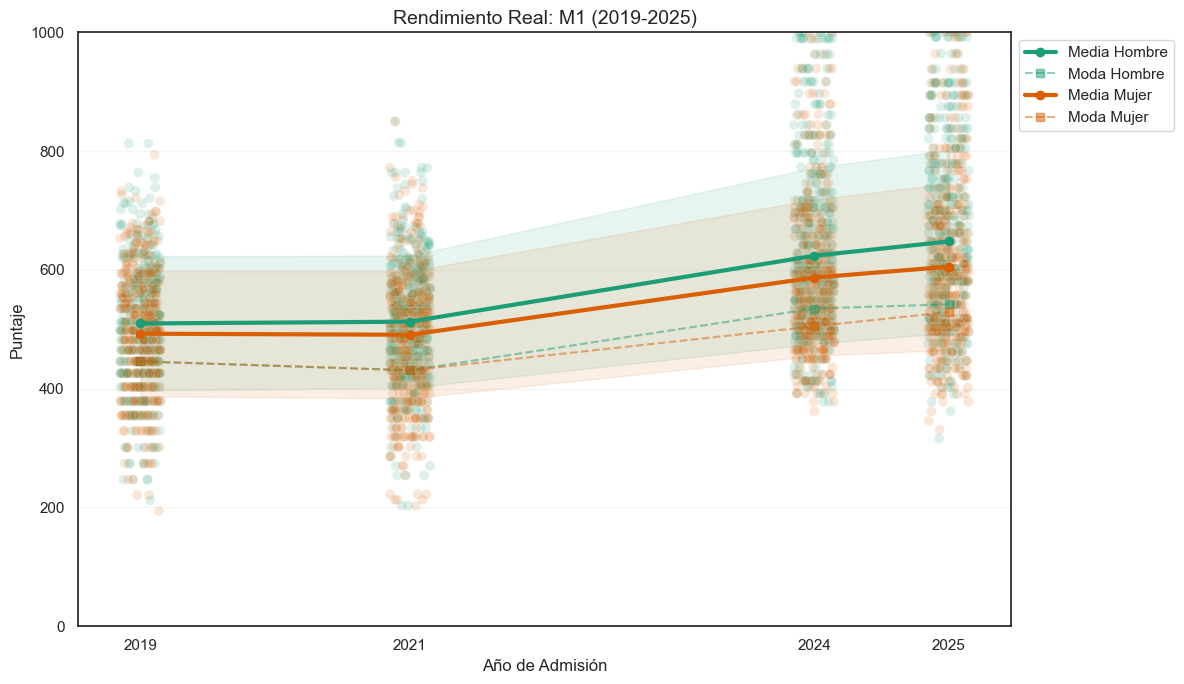

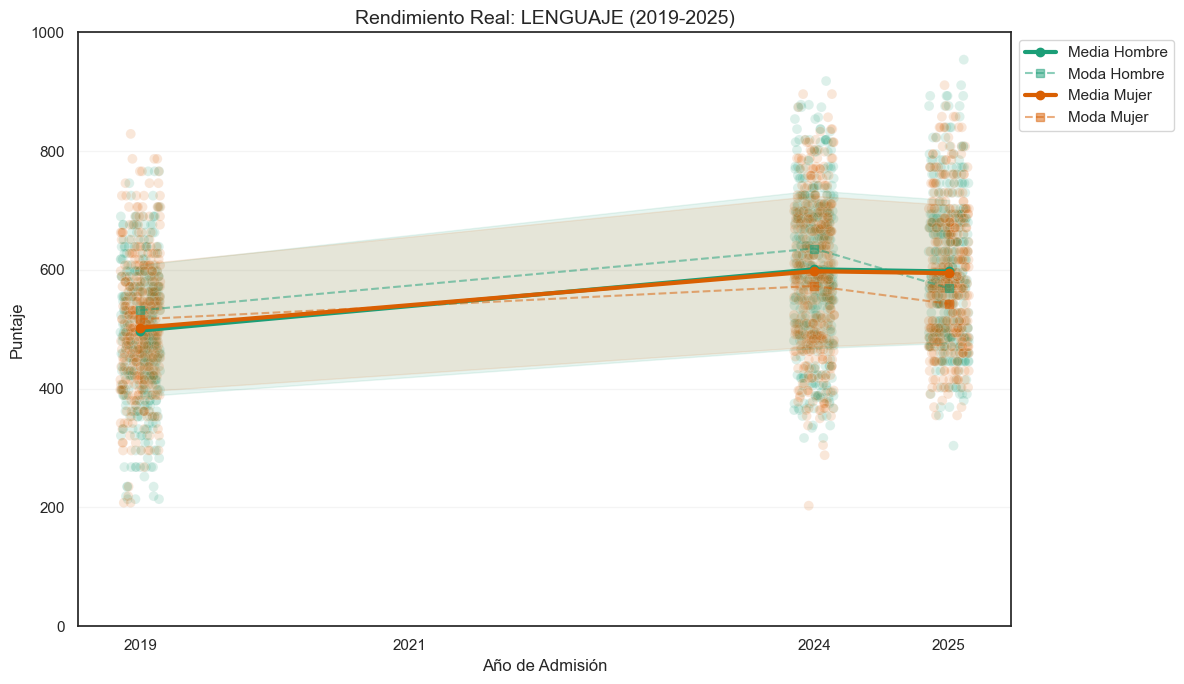

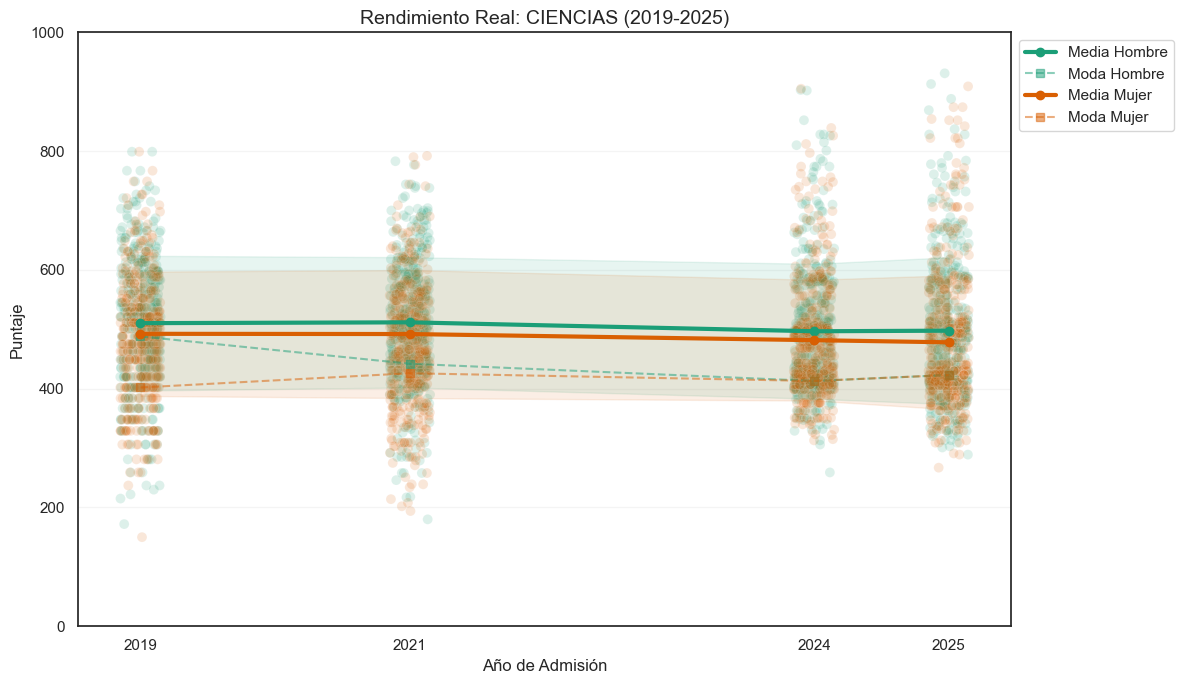

In [17]:
for prueba in df_stats['Prueba'].unique():
    plt.figure(figsize=(12, 7))
    stats_p = df_stats[df_stats['Prueba'] == prueba]
    pts_p = df_pts[df_pts['Prueba'] == prueba]
    
    # Dibujamos la nube de puntos (s=50 para que se vean grandes)
    sns.scatterplot(
        data=pts_p, x='Año_Jitter', y='Puntaje', hue='Genero', 
        palette=colores_genero, alpha=0.15, s=50, legend=False
    )
    
    for g in ['Hombre', 'Mujer']:
        color = colores_genero[g]
        data_g = stats_p[stats_p['Genero'] == g]
        
        # Sombra de dispersión
        plt.fill_between(data_g['Año'], data_g['Std_Inf'], data_g['Std_Sup'], color=color, alpha=0.1)
        
        # Línea de la Media (Sólida)
        plt.plot(data_g['Año'], data_g['Media'], marker='o', color=color, lw=3, label=f'Media {g}')
        
        # Línea de la Moda (Punteada)
        plt.plot(data_g['Año'], data_g['Moda'], marker='s', ls='--', color=color, alpha=0.5, label=f'Moda {g}')

    plt.ylim(0, 1000)
    plt.title(f'Rendimiento Real: {prueba} (2019-2025)', fontsize=14)
    plt.ylabel('Puntaje')
    plt.xlabel('Año de Admisión')
    plt.xticks(años)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(axis='y', alpha=0.2)
    
    plt.tight_layout()
    plt.show()